# Visualizing Distribution

This section shows a few ways that we can visualize distributions of data points in python. In many datasets, the distribution of values can be quite complex: spread across multiple peaks, not just a single mean and points normally distributed around it. Because of this, *visualizing* distibutions of data, not just simple averages and their standard deviation, can be critical for finding interesting and important patterns in your data.

In this section we will talk a little about the idea of a statistical distribution, and then show examples of how to write python code to visualize distributions with categorical strip plots, overlaid histograms, and Kernal Density Estimation plots.

## In this section
- This section describes how to make a few common graph types in matplotlib

## Prerequisites

## Table of Content
* [In this section](#In-this-section)
* [Prerequisites](#Prerequisites)
* [Main Text](#Main-text)
* [Subheading](#Subheading)
* [Subheading 2](#Subheading-2)

In [81]:
## Visualizing Distributions.

## Counting Crows

We'll use observations of crows as a dataset to do some basic visualizations. Ute *et al.,* 2018 compared counts of crows across different areas of a large zoo. This allowed for comparisons across date, time of day, subspecies of crow, crow behavior, etc. As some enclosures had forested areas or potential predators of crow, it also allowed comparison of some features of each enclosure's environment.

Visualizing a large dataset like this one is a good exercise in thinking about data visualization. It will immediately become clear that we probably can't show all possible features of the data all at once and have our graphs still be useful. Instead, we will need to build different data visualizations to address different questions we might want to ask in the data.

In a final manuscript, the choice of data visualization you use in a paper will be tightly linked to the biological hypothesis you are testing and the statistical tests you are using to test it. However, before you get to that point, it can be useful to create multiple visualizations to get familiar with a dataset. These help orient you to major features of the data, and also serve as a quality control check to make sure there aren't any data that need to be double checked for accuracy (e.g. one coral dataset I worked with had temperature readings of 99999 °C representing missing data that needed to be excluded from averages).

### Load Crow Count Data from Ute et al., 2018

Let's begin by downloading the Ute *et al.* 2018 dataset. You can get a copy [here](./resources/CC_Data.csv). A

We will load the data using pandas. 

In [82]:
import pandas as pd

crow_count_data = pd.read_csv("./resources/CC_Data.csv", sep=";")
crow_count_data = crow_count_data.set_index("Index")
crow_count_data.head()

,Date,Time,Weather,Temperature,Visitors,Subspecies,Marking,Age,Individual,Behaviour,Group_Size,Forested_Area,Dangerous_Enclosure,Area,Time_of_Day,Season,On_Building,Crows_per_Scan
Index,,,,,,,,,,,,,,,,,,
1,2014-01-08,953,Clouds,Cold,Few,HY,Unmarked,NaN,NaN,Foraging,1,1,0,0,Morning,Non-Breeder_Season,1,53
2,2014-01-08,954,Clouds,Cold,Few,HH,Unmarked,NaN,NaN,Foraging,1,1,0,0,Morning,Non-Breeder_Season,1,53
3,2014-01-08,956,Clouds,Cold,Few,CH,Unmarked,NaN,NaN,Foraging,1,1,0,0,Morning,Non-Breeder_Season,1,53
4,2014-01-08,957,Clouds,Cold,Few,CH,Marked,Adult,242,Foraging,1,1,0,0,Morning,Non-Breeder_Season,1,53
5,2014-01-08,1000,Clouds,Cold,Few,H,Unmarked,NaN,NaN,Foraging,1,1,0,0,Morning,Non-Breeder_Season,1,53


### Import graphing and numeric libraries

The examples in this chapter will use `matplotlib` for graphing and `numpy` for some numerical work. Let's import these libraries before we use them:

In [83]:
import matplotlib.pyplot as plt
import numpy as np

### Define custom colors 

Color can be a powerful tool in communicating information in graphs. It's often useful to be able to define custom colors so your graphs can be accessible (i.e. not include color combinations that look the same to folks with common types of colorblindness) and look the way you want.

In cases where specific colors are likely to have meaning for your audience, it's useful if the colors you pick can line up with what the audience expects. For example, if comparing marine vs. terrestrial vertebrates, it would be a very bad choice to color the terrestrial vertebrate data blue and the marine data brown! 

All that being said, if we don't know how to set up colors ourselves, then we might be tempted to just go with default values. It turns out that in matplotlib it is relatively easy to define custom colors. 

These can be represented as tuples — an immutable version of lists — of red, green, and blue (RGB) values between 0.0 and 1.0. This is slightly weird, since RGB values are typically defined between 0.0 and 255.0. Therefore, to translate colors we tested in a paint program or an online palette into matplotlib, we generally have to divide each value by 255.

Numpy arrays provide a convenient way to do that, because dividing an array by a number divides each element of the array by that number. So if we enter the RBG values we want as arrays — like `np.array([10.0,0.0,255])` — we can then divide the array by 255.0. If we call `tuple()` on the result, it will convert our array into a tuple.

Finally, many matplotlib functions want lists of colors to represent categories. It can be shockingly difficult to find large numbers of colors that are all clearly distinct if you have more than, say, 12 categories. In this case we'll limit ourselves to no more than 4 categories distinguished by color at a time, which should be a number that allows for very distinct colors, even to those like me who don't have perfect color vision.

In [84]:

## Set up colors we can use throughout our examples

# Produce tuples of RGB values to define colors in matplotlibs 0.0 - 1.0 scale
# End result is something like (1.0,0.0,0.0) for Red

bright_green = tuple(np.array([146.0, 249.0, 11.0]) / 255.0)
orange = tuple(np.array([253.0, 173.0, 1.0]) / 255.0)
magenta = tuple(np.array([255.0, 19.0, 170.0]) / 255.0)
deep_blue = tuple(np.array([11.0, 79.0, 175.0]) / 255.0)

#Add our colors to a list for use in graphs

colors = [orange, magenta, deep_blue, bright_green]



## Visualize Data Points across Categories with Strip Plots 



<img src="./stripplot.png" width="400" alt="Stripplot showing group sizes by category with jittered points and average markers" align="left" >




Strip plots are a way of showing the individual points in a dataset. Whereas a traditional bar chart often shows only the average value and a standard deviation or standard error around it, strip plots allow the individual data points contributing to the average to be shown.

This doesn't matter too much if the data are all normally distributed. However, any time data are not perfectly normal, seeing the distribution of the data can help avoid misleading interpretations.


Let's write a function to generate a strip plot by hand. This will be a somewhat more involved example, but if you analyze the code, you can find some examples of how to jitter data (used in many categorical graph types), use dictionaries to map colors to points, etc. 

**Try it yourself**: I've added more extensive comments than normal and even some section headers. Check out the code and see if you can figure out how it works. One good way to see if you get it is to try building up the function a bit at a time, adding print statements to check the value of any variables you aren't sure of.


In [85]:
def make_two_category_scatterplot(x, y, category_labels, output_file="./stripplot.png", point_size=10.0,
                                  x_label="Category", y_label="Value", axis_margin=0.33,
                                  colors=None, x_jitter=0.15):
    """Generate a two category stripplot"""
    
    
    ###################################### SET UP COLORS ########################################
    
    #If the user doesn't pass in colors, use orange and magenta
    if colors is None:
        colors = ["cyan", "darkorange"]
        
        
    #Set up a figure and axis object. fig is the overall figure, the ax is the specific graph.
    #This distinction mostly matters when making figures that have subplots in them.
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
    
    #Once we have our colors, we ned to assign each point to a specific color.
    #In this case, only the x-axis category matters for color. We want our code
    #to work with any number of categories (as long as there are also that many colors)
    #so we use a dict comprehension to loop over all the x values and assign each a color.
    
    colormap = {}
    for i, val in enumerate(list(x.unique())):
            colormap[val] = colors[i]
    
    #A more compact, but maybe less readable way to do this is with a
    #dict comprehension:
    
    #colormap = {val: colors[i] for i, val in enumerate(list(x.unique()))}
    
    #Now we set the values of all our actual points using our dict
    #The syntax here is a list comprehension (equivalent to a for loop but shorter to write)
    point_colors = [colormap[x_val] for x_val in x]

    
    
    
    ####################### PLOT JITTERED STRIP PLOT POINTS ###############################

    #In data visualization, a 'jitter' is a random value added to a point to avoid overlap.
    #For a strip plot, we want to add jitter so that our points can spread out to fill the
    #area of their category, allowing multiple points at similar y to be seen by spreading
    #them out a little along the x axis. Here we use random values drawn from a normal 
    #(i.e. Gaussian or Bell-curve) distribution to represent our scatter
    
    N = len(x)
    x_jitter_vals = np.random.normal(loc=0.0, scale=x_jitter, size=N)
    
    x_numeric = x.astype(float) + x_jitter_vals

    ax.scatter(x=x_numeric, y=y, s=point_size, c=point_colors, edgecolor='white', alpha=0.75)

    ############################### PLOT AVERAGE VALUES ####################################
    
    #We probably want to show average values for our categories
    #To do that, we can get the average in each category and add it to a list.
    #Then we can just plot big black points or bars to represent each average.
    
    
    # Average only the group sizes for the crows in a dangerous enclosure
    averages = []
    for category in x.unique():
        average = np.average(y[x == category])
        averages.append((category, average))

    print("AVERAGES:", averages)

    #Loop over our different categories and plot the average of each
    for category, y_average in averages:
        ax.scatter(x=float(category), y=y_average, s=point_size*250, 
                   facecolor='black', alpha=1.0, marker="_")   

    ####################### Adjust the look of axes ###############################
   
    ax.set_xlabel(x_label, fontname='Helvetica', fontsize='x-large')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(category_labels, fontsize='x-large')
    ax.tick_params(direction='in')
    
    ax.set_xlim(min(x_numeric) - axis_margin, max(x_numeric) + axis_margin)
    ax.set_ylabel(y_label, fontname='Helvetica', fontsize='x-large')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.savefig(output_file)

### Running our strip plot code to visualize crow counts

AVERAGES: [(0, 3.258502553880653), (1, 3.779384035197989)]


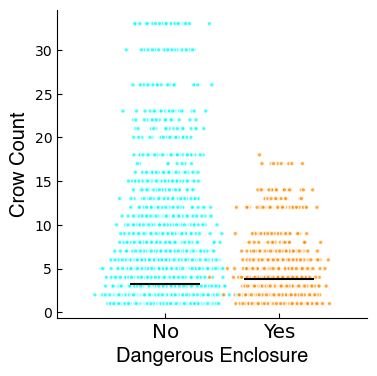

In [86]:
x = crow_count_data['Dangerous_Enclosure']
y = crow_count_data['Group_Size']
make_two_category_scatterplot(x, y, category_labels=['No', 'Yes'],\
                              x_label = "Dangerous Enclosure", y_label="Crow Count")

## Visualize distribution with a Kernal Density Estimation (KDE) plot

For category 0, we have 16054 y values.
For category 1, we have 1591 y values.


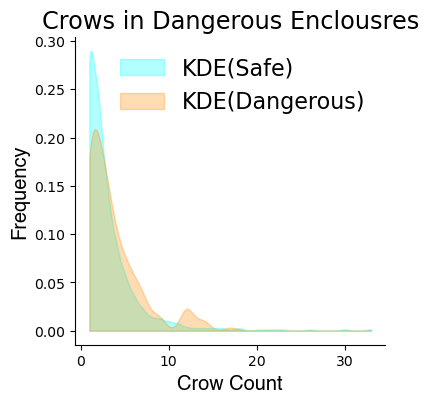

In [87]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

#Set up a figure and axis object. fig is the overall figure, the ax is the specific graph.
#This distinction mostly matters when making figures that have subplots in them.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
data_by_category = {}
colors = ["cyan", "darkorange"]
labels = ["Safe","Dangerous"]
x_val_list = list(x)

# Define the x-points for the plot
x_vals = np.linspace(y.min(), y.max(), 1000)

for i,category in enumerate(list(x.unique())):
    
    category_y_vals = [y for i,y in enumerate(y) if x_val_list[i] == category]
    print(f"For category {category}, we have {len(category_y_vals)} y values.")

    # Calculate the KDE estimator
    # NOTE: we will use this below to get actual density values
    # for our ***x-axis*** values.
    kde = gaussian_kde(category_y_vals)

    
    # Evaluate the KDE at the x-points
    density_vals = kde(x_vals)
    
    #Pick a color to shade in the KDE
    color = colors[i]
    label = labels[i]

    # Plot the results using standard Matplotlib functions
    plt.fill_between(x_vals, density_vals, color=color,alpha=0.3, label=f'KDE({label})')

# Remove some unnecessary parts of the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("Crows in Dangerous Enclousres",size = "xx-large")
plt.xlabel("Crow Count", fontname = "Helvetica", size = "x-large")
plt.ylabel("Frequency", fontname = "Helvetica", size = "x-large")
plt.legend(fontsize= 16, frameon=False,loc="upper right", alignment="right")
plt.show()


## Visualizing Distributions with Histograms

Histograms are a common way to visualize distributions. For categorical data, overlaid histograms can help to show where the frequency of data values differs across categories. They usually work best when the two datasets are quite different, so the histograms don't overlap too much. 

Below, we'll see one example of how to visualize categorical data with overlapping histograms

### Visualize Data Distribution with Overlaid Histograms

In [90]:
def plot_multiple_histogram(datasets, colors, labels, outfile, title=None):
    """
    Plot a multiple histogram of several datasets
    datasets -- list of data
    colors -- list of colors
    labels -- list of labels
    outfile -- file location to save histogram
    title -- optional title string
    """
    fontsize = 16
    if len(colors) < len(datasets):
        raise ValueError("Need to specify one color per dataset")

    if len(labels) < len(datasets):
        raise ValueError("Need to specify one label per dataset")

    fig, ax = plt.subplots()
    all_data = []
    for d in datasets:
        all_data.extend(d)
    max_val = max(map(int, all_data))
    bins = np.linspace(0, max_val, 15)

    plt.xlabel("Value", fontsize=fontsize)
    plt.ylabel("Frequency", fontsize=fontsize)

    common_params = {'histtype': 'stepfilled', 'alpha': 0.50, 'bins': bins, 'edgecolor': 'black'}
    print("Plotting histogram")

    for i, dataset in enumerate(datasets):
        ax.hist(dataset, facecolor=colors[i], label=labels[i], density=True, **common_params)

    # Remove axis lines.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if title:
        plt.title(title,fontsize=fontsize)

    #make the legend text a bit smaller than the axis titles
    legend_fontsize = fontsize*0.65
    
    plt.legend(fontsize= legend_fontsize, frameon=False,loc="upper right", alignment="right")
    plt.savefig(outfile)
    

### Plot a Histogram of Number of Crows in Safe Vs. Dangerous Enclosures

Plotting histogram


<Figure size 640x480 with 0 Axes>

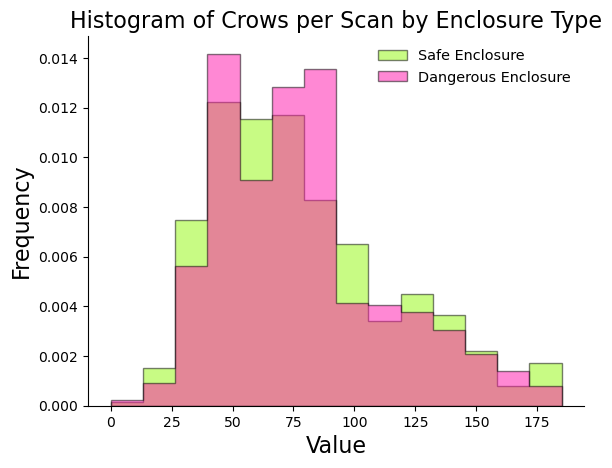

In [91]:
%matplotlib inline
datasets = [
    crow_count_data[crow_count_data['Dangerous_Enclosure'] == 0]['Crows_per_Scan'].dropna().values,
    crow_count_data[crow_count_data['Dangerous_Enclosure'] == 1]['Crows_per_Scan'].dropna().values
]

colors = [bright_green, magenta]
labels = ['Safe Enclosure', 'Dangerous Enclosure']
outfile = './multiple_histogram_by_enclosure_type.png'
title = 'Histogram of Crows per Scan by Enclosure Type'
plt.clf()
plot_multiple_histogram(datasets, colors, labels, outfile, title=title)
plt.show()

## Exercises

1. Of the different ways of visualizing the data up above, which do you prefer? Why?

2. Examine the Crow Count dataset in Excel or Google Sheets. Pick a different column other than dangerous enclosures (perhaps the Forested category). See if you can visualize the distribution of Crow Counts according to your category. 

3. Instead of using the default colors, try defining your own colors using the method shown at the start of the chapter. To do this you would a) pick colors for each category b) find their RGB values (you can find these for common colors online) c) set up each color as shown in the chapter d) put them in order in a list of colors e) pass that list into the functions.  If you did exercise 2, you could pick colors to represent forested or non-forested enclosures in the zoo,

## Reading Responses & Feedback 

^Make this a hyperlink using Google Forms

## Further Reading

## References